<a href="https://colab.research.google.com/github/KaterinSalazar/biosignals/blob/main/Proyecto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Informe proyecto 2 · Bioseñales y Sistemas 2026-01 · Universidad de Antioquia

##Integrantes:
##Cesar Arredondo
##Katerin Salazar

## Objetivos

1. Desarrollar un pipeline de extracción de características espectrales a partir de señales EEG de dos canales (C3 y C4), que capture los fenómenos de desincronización relacionada con eventos y lateralización hemisférica asociados a las condiciones de reposo e imaginación motora de mano izquierda y derecha.

2. Evaluar y comparar el desempeño de diferentes modelos de clasificación, incluyendo redes neuronales MLP bajo reglas heurísticas de diseño, máquina de soporte vectorial y XGBoost, para la discriminación sujeto-independiente de las tres condiciones experimentales mediante validación cruzada por grupos.

3. Identificar las características espectrales con mayor poder discriminativo entre condiciones experimentales y analizar su coherencia con la fisiología del sistema motor, con el fin de fundamentar el diseño de una interfaz cerebro-máquina basada en imaginación motora.


In [ ]:
!pip install mne
!pip install scikit-posthocs
!pip install openneuro-py
!pip install gdown

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Importaciones
# ─────────────────────────────────────────────────────────────────────────────
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import warnings
from scipy.signal import welch,csd
from openneuro import download
import os
import mne
import seaborn as sns
from scipy import stats
from scikit_posthocs import posthoc_dunn

warnings.filterwarnings('ignore')

from sklearn.model_selection import (GroupKFold,
                                     cross_val_predict, GridSearchCV)
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.svm             import SVC
from sklearn.metrics         import (confusion_matrix, ConfusionMatrixDisplay,
                                     classification_report, accuracy_score)
from sklearn.neural_network  import MLPClassifier
from xgboost                 import XGBClassifier

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


In [ ]:
#Descarga de archivos, esperar 5 minutos
download(
    dataset="ds004362",
    target_dir="datos",
    include=[
        "sub-*/eeg/*run-3*_eeg.set",
        "sub-*/eeg/*run-4*_eeg.set",
        "sub-*/eeg/*run-7*_eeg.set",
        "sub-*/eeg/*run-8*_eeg.set",
        "sub-*/eeg/*run-11*_eeg.set",
        "sub-*/eeg/*run-12*_eeg.set",
    ]
)


👋 Hello! This is openneuro-py 2026.4.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/openneuro-py/openneuro-py/issues

🌍 Preparing to download ds004362 …
📥 Retrieving up to 659 files (5 concurrent downloads). 

✅ Finished downloading ds004362.
 
🧠 Please enjoy your brains.
 


In [ ]:
"""
Pipeline EEG — Extracción de características espectrales  v3
=============================================================
Cambios respecto a v1:

  CAMBIO 1 — compute_spectral_features()
    Se agrega potencia relativa por banda (<CH>_<banda>_rel):
        p_rel = p_banda / p_total(1–40 Hz)
    Oscila entre 0 y 1, invariante al nivel absoluto del sujeto y al canal.
    La potencia absoluta (<CH>_<banda>) se conserva porque ERD y LI la necesitan.

  CAMBIO 2 — procesar_sujetos()
    Se agrega z-score por sujeto al final (igual que v2) sobre TODAS
    las columnas numéricas, cubriendo ERD, SE e IHC que siguen siendo absolutas.
    La potencia relativa ya es invariante, pero el z-score no la daña
    (simplemente la re-centra, lo que es inofensivo).
"""
mne.set_log_level('ERROR')

RUNS_REAL      = [3, 7, 11]
RUNS_IMAGINADO = [4, 8, 12]
RUNS_VALIDOS   = RUNS_REAL + RUNS_IMAGINADO
TMIN, TMAX     = -1.0, 4.0
RUN_TO_TASK    = {3: 1, 4: 2, 7: 1, 8: 2, 11: 1, 12: 2}

BANDS = {'mu': (8, 13), 'beta': (13, 30)}
CHANNELS_OF_INTEREST = ['C3', 'C4']

# Rango de referencia para potencia relativa
FREQ_REF = (5, 35)


# ──────────────────────────────────────────────────────────────────────────────
# Funciones auxiliares — sin cambios
# ──────────────────────────────────────────────────────────────────────────────
def cargar_raw(data_dir, sujeto, run):
    archivo = (f"{data_dir}/datos/{sujeto}/eeg/"
               f"{sujeto}_task-motion_run-{run}_eeg.set")
    return mne.io.read_raw_eeglab(archivo, preload=True)

def preprocesar(raw):
    raw.filter(l_freq=7.0, h_freq=35.0, method='fir',
               fir_window='hamming', phase='zero')
    raw.set_eeg_reference(ref_channels='average', projection=False)
    return raw

def segmentar_epocas(raw_clean, run, min_epocas=5):
    events, event_id = mne.events_from_annotations(raw_clean)
    task_num = RUN_TO_TASK[run]
    epoch_event_id = {
        'T0': event_id[f'TASK{task_num}T0'],
        'T1': event_id[f'TASK{task_num}T1'],
        'T2': event_id[f'TASK{task_num}T2'],
    }
    epochs = mne.Epochs(raw_clean, events, event_id=epoch_event_id,
                        tmin=TMIN, tmax=TMAX, baseline=None,
                        reject=None, preload=True, verbose=False)
    c3_idx = epochs.ch_names.index('C3')
    c4_idx = epochs.ch_names.index('C4')
    data   = epochs.get_data()
    mask   = ((np.abs(data[:, c3_idx, :]).max(axis=-1) <= 100e-6) &
              (np.abs(data[:, c4_idx, :]).max(axis=-1) <= 100e-6))
    epochs = epochs[mask]
    print(f"  Umbral 100 µV → {len(epochs)} épocas ✓")
    return epochs

def get_condition(run, event_code):
    if event_code == 1: return 'rest'
    es_real = run in RUNS_REAL
    if event_code == 2: return 'real_left'  if es_real else 'mi_left'
    if event_code == 3: return 'real_right' if es_real else 'mi_right'
    return 'unknown'


# ──────────────────────────────────────────────────────────────────────────────
# PUNTO 1 — compute_spectral_features  (v3: + potencia relativa)
# ──────────────────────────────────────────────────────────────────────────────
def compute_spectral_features(
        epoch_data,
        sfreq,
        bands=BANDS,
        channels=CHANNELS_OF_INTEREST,
        freq_ref=FREQ_REF):

    ep_uv = epoch_data * 1e6  # V → µV

    features = {}

    # ============================================================
    # PSD de la época completa
    # ============================================================
    freqs, psd = welch(
        ep_uv,
        fs=sfreq,
        nperseg=min(256, ep_uv.shape[1]),
        noverlap=min(128, max(0, ep_uv.shape[1]//2)),
        window='hann',
        axis=-1
    )

    has_c3 = 'C3' in channels
    has_c4 = 'C4' in channels

    if has_c3:
        i_c3 = channels.index('C3')

    if has_c4:
        i_c4 = channels.index('C4')

    # ============================================================
    # POTENCIA ABSOLUTA + RELATIVA
    # ============================================================
    idx_ref = (freqs >= freq_ref[0]) & (freqs <= freq_ref[1])

    for band, (flo, fhi) in bands.items():

        idx_band = (freqs >= flo) & (freqs <= fhi)

        for ch_i, ch in enumerate(channels):

            p_band = np.trapezoid(
                psd[ch_i, idx_band],
                freqs[idx_band]
            )

            p_ref = np.trapezoid(
                psd[ch_i, idx_ref],
                freqs[idx_ref]
            )

            features[f'{ch}_{band}'] = p_band / (fhi - flo)

            features[f'{ch}_{band}_rel'] = (
                p_band / (p_ref + 1e-10)
            )

    # ============================================================
    # LI CLÁSICO
    # ============================================================
    if has_c3 and has_c4:

        for band in bands:

            p3 = features[f'C3_{band}']
            p4 = features[f'C4_{band}']

            features[f'LI_{band}'] = (
                (p4 - p3) /
                (p4 + p3 + 1e-10)
            )

    # ============================================================
    # ERD
    # baseline = [-1,0]
    # tarea    = [0,4]
    # ============================================================
    baseline_mask = np.arange(ep_uv.shape[1]) < sfreq
    task_mask     = np.arange(ep_uv.shape[1]) >= sfreq

    baseline_data = ep_uv[:, baseline_mask]
    task_data     = ep_uv[:, task_mask]

    for band, (flo, fhi) in bands.items():

        for ch_i, ch in enumerate(channels):

            freqs_b, psd_b = welch(
                baseline_data[ch_i],
                fs=sfreq,
                nperseg=min(256, baseline_data.shape[1])
            )

            freqs_t, psd_t = welch(
                task_data[ch_i],
                fs=sfreq,
                nperseg=min(256, task_data.shape[1])
            )

            idx_b = (freqs_b >= flo) & (freqs_b <= fhi)
            idx_t = (freqs_t >= flo) & (freqs_t <= fhi)

            P_baseline = np.trapezoid(
                psd_b[idx_b],
                freqs_b[idx_b]
            )

            P_task = np.trapezoid(
                psd_t[idx_t],
                freqs_t[idx_t]
            )

            erd = 100 * (
                (P_baseline - P_task) /
                (P_baseline + 1e-10)
            )

            features[f'{ch}_{band}_ERD'] = erd

    # ============================================================
    # LI basado en ERD
    # ============================================================
    if has_c3 and has_c4:

        for band in bands:

            erd_c3 = features[f'C3_{band}_ERD']
            erd_c4 = features[f'C4_{band}_ERD']

            features[f'LI_ERD_{band}'] = (
                (erd_c4 - erd_c3) /
                (abs(erd_c4) + abs(erd_c3) + 1e-10)
            )

    # ============================================================
    # ENTROPÍA ESPECTRAL
    # ============================================================
    idx_se = (freqs >= 8) & (freqs <= 30)

    psd_band = psd[:, idx_se]

    psd_norm = (
        psd_band /
        (psd_band.sum(axis=-1, keepdims=True) + 1e-10)
    )

    se = -(
        psd_norm *
        np.log2(psd_norm + 1e-10)
    ).sum(axis=-1)

    for ch_i, ch in enumerate(channels):
        features[f'{ch}_SE'] = se[ch_i]

    # ============================================================
    # COHERENCIA INTERHEMISFÉRICA
    # ============================================================
    if has_c3 and has_c4:

        _, s_cross = csd(
            ep_uv[i_c3],
            ep_uv[i_c4],
            fs=sfreq,
            nperseg=min(256, ep_uv.shape[1]),
            noverlap=min(128, ep_uv.shape[1] // 2),
            window='hann'
        )

        for band, (flo, fhi) in bands.items():

            idx_band = (
                (freqs >= flo) &
                (freqs <= fhi)
            )

            coh = (
                np.abs(s_cross[idx_band])**2 /
                (
                    psd[i_c3, idx_band] *
                    psd[i_c4, idx_band] +
                    1e-10
                )
            )

            features[f'IHC_{band}'] = coh.mean()

    return features



In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# PUNTO 2 — procesar_sujetos  (v3: + columnas _rel + z-score por sujeto)
# ──────────────────────────────────────────────────────────────────────────────
def procesar_sujetos(data_dir, n_sujetos=None, sujeto_id=None,
                     visualizar=False,
                     channels=CHANNELS_OF_INTEREST,
                     bands=BANDS):
    """
    Pipeline completo: carga → filtrado → épocas → características → DataFrame.

    CAMBIO 2 — Z-score por sujeto
    ──────────────────────────────
    La potencia relativa (_rel) ya es invariante entre sujetos, pero ERD, SE
    e IHC todavía son absolutas. El z-score por sujeto cubre todas las columnas
    numéricas de una vez:
        z = (x − µ_sujeto) / σ_sujeto     ----------------------------------#JUSTIFICAR---------------
    Sobre _rel el z-score es inofensivo: simplemente re-centra valores que
    ya estaban bien escalados.
    """
    if sujeto_id is not None:
        lista_sujetos = [sujeto_id]
    elif n_sujetos is not None:
        lista_sujetos = list(range(1, n_sujetos + 1))
    else:
        raise ValueError("Debes especificar 'sujeto_id' o 'n_sujetos'.")

    records, epocas_guardadas, infosignal = [], {}, None

    for j in lista_sujetos:
        sujeto = f"sub-{j:03d}"
        print(f"\n{'='*50}\nProcesando {sujeto} ...\n{'='*50}")

        for run in RUNS_VALIDOS:
            print(f"  Run {run:02d} ...", end=" ")
            try:
                raw          = cargar_raw(data_dir, sujeto, run)
                raw_filtrada = preprocesar(raw.copy())
                epochs       = segmentar_epocas(raw_filtrada, run)
                epocas_guardadas[(sujeto, run)] = epochs

                if infosignal is None:
                    infosignal = raw_filtrada.info
                if visualizar:
                    graficar(raw, raw_filtrada)

                sfreq    = raw_filtrada.info['sfreq']
                ch_names = [ch.upper() for ch in raw_filtrada.ch_names]
                ch_idx   = [ch_names.index(ch.upper()) for ch in channels]

                for ep_i, ep_data in enumerate(epochs.get_data()[:, ch_idx, :]):
                    event_code = epochs.events[ep_i, 2]
                    feats = compute_spectral_features(ep_data, sfreq,
                                                      bands, channels)
                    records.append({
                        'subject'  : sujeto,
                        'run'      : run,
                        'condition': get_condition(run, event_code),
                        'epoch_idx': ep_i,
                        **feats,
                    })

                tipo = "real" if run in RUNS_REAL else "imaginado"
                print(f"✓ Movimiento {tipo} — {len(epochs)} épocas\n")

            except Exception as e:
                print(f"✗  Skipped: {e}")
                continue

    # ── Construcción del DataFrame ───────────────────────────────────────────
    df_final = pd.DataFrame(records)

    meta_cols = ['subject', 'run', 'condition', 'epoch_idx']

    erd_cols = [
        'C3_mu_ERD',
        'C4_mu_ERD',
        'C3_beta_ERD',
        'C4_beta_ERD',
        'LI_ERD_mu',
        'LI_ERD_beta'
    ]

    rel_cols = [
        f'{ch}_{b}_rel'
        for ch in channels
        for b in bands
    ]

    li_cols = [
        f'LI_{b}'
        for b in bands
    ]

    se_cols = [
        f'{ch}_SE'
        for ch in channels
    ]

    ihc_cols = [
        f'IHC_{b}'
        for b in bands
    ]

    all_cols = (
        meta_cols +
        erd_cols +
        rel_cols +
        li_cols +
        se_cols +
        ihc_cols
    )

    df_final = df_final[
        [c for c in all_cols if c in df_final.columns]
    ]
    # ── CAMBIO 2: z-score por sujeto ────────────────────────────────────────
    feat_cols = [c for c in df_final.columns if c not in meta_cols]
    df_final[feat_cols] = (
        df_final
        .groupby('subject')[feat_cols]
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-10))
    )



    df_final.to_csv("df_final.csv", index=False)
    return df_final, infosignal, epocas_guardadas

In [ ]:
# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────

DATA_DIR = "/content"

print("=" * 50)
print("   PIPELINE EEG — Motor Imagery BCI")
print("=" * 50)
print("\n¿Qué deseas procesar?")
print("  1. Un solo sujeto ")
print("  2. Varios sujetos ")
print("-" * 50)

while True:
    opcion = input("Selecciona una opción [1/2]: ").strip()
    if opcion in ['1', '2']:
        break
    print("  ⚠ Opción inválida — ingresa 1 o 2")

if opcion == '1':
    while True:
        try:
            n = int(input("Número del sujeto (ej. 1 para sub-001): ").strip())
            if 1 <= n <= 109:
                break
            print("  ⚠ El número debe estar entre 1 y 109")
        except ValueError:
            print("  ⚠ Ingresa un número entero válido")

    print(f"\n  ► Procesando sub-{n:03d} con visualización de gráficas...")
    print("=" * 50)
    df, infosignal, epocas = procesar_sujetos(DATA_DIR, sujeto_id=n, visualizar=False)

else:
    while True:
        try:
            n = int(input("¿Cuántos sujetos deseas procesar? (1-109): ").strip())
            if 1 <= n <= 109:
                break
            print("  ⚠ El número debe estar entre 1 y 109")
        except ValueError:
            print("  ⚠ Ingresa un número entero válido")

    print(f"\n  ► Procesando {n} sujeto(s) sin visualización de gráficas...")
    print("  ► Esto puede tardar varios minutos.")
    print("=" * 50)
    df, infosignal, epocas = procesar_sujetos(DATA_DIR, n_sujetos=n, visualizar=False)

print("\nPipeline finalizado.")
print(f"DataFrame: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

   PIPELINE EEG — Motor Imagery BCI

¿Qué deseas procesar?
  1. Un solo sujeto 
  2. Varios sujetos 
--------------------------------------------------
Selecciona una opción [1/2]: 2
¿Cuántos sujetos deseas procesar? (1-109): 109

  ► Procesando 109 sujeto(s) sin visualización de gráficas...
  ► Esto puede tardar varios minutos.

Procesando sub-001 ...
  Run 03 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento real — 29 épocas

  Run 07 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento real — 29 épocas

  Run 11 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento real — 29 épocas

  Run 04 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento imaginado — 29 épocas

  Run 08 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento imaginado — 29 épocas

  Run 12 ...   Umbral 100 µV → 29 épocas ✓
✓ Movimiento imaginado — 29 épocas


Procesando sub-002 ...
  Run 03 ...   Umbral 100 µV → 27 épocas ✓
✓ Movimiento real — 27 épocas

  Run 07 ...   Umbral 100 µV → 28 épocas ✓
✓ Movimiento real — 28 épocas

  Run 11 ...  

,subject,run,condition,epoch_idx,C3_mu_ERD,C4_mu_ERD,C3_beta_ERD,C4_beta_ERD,LI_ERD_mu,LI_ERD_beta,C3_mu_rel,C3_beta_rel,C4_mu_rel,C4_beta_rel,LI_mu,LI_beta,C3_SE,C4_SE,IHC_mu,IHC_beta
0,sub-001,3,real_right,0,0.223390,0.602349,-0.292662,1.202019,1.353077,1.443615,-1.064307,1.696600,0.825235,-1.092238,1.365005,-1.115158,0.425241,-0.065493,1.885774,2.455991
1,sub-001,3,rest,1,-0.303590,0.403688,0.341148,0.424689,1.353077,0.021185,-0.691151,1.029063,-0.076093,0.313177,-0.242264,-1.554809,0.975050,1.048429,-0.901604,-1.817583
2,sub-001,3,real_left,2,0.047161,0.418730,0.905304,0.977132,1.353077,-0.014258,-0.170123,0.083363,-0.580762,0.335389,0.045527,0.590617,0.529451,0.541960,1.625872,0.134543
3,sub-001,3,rest,3,0.415231,-0.897695,-0.001474,-1.444232,-1.313195,-0.871247,-2.126346,1.724908,-0.740752,0.675321,1.054680,-1.350285,-0.033589,0.644222,-0.897932,0.187396
4,sub-001,3,real_left,4,1.000801,0.691755,1.060700,0.896332,-0.076204,-0.226837,-1.772789,0.792582,-1.323847,1.827126,0.205252,-0.398675,-1.995459,1.766268,0.508213,0.484333


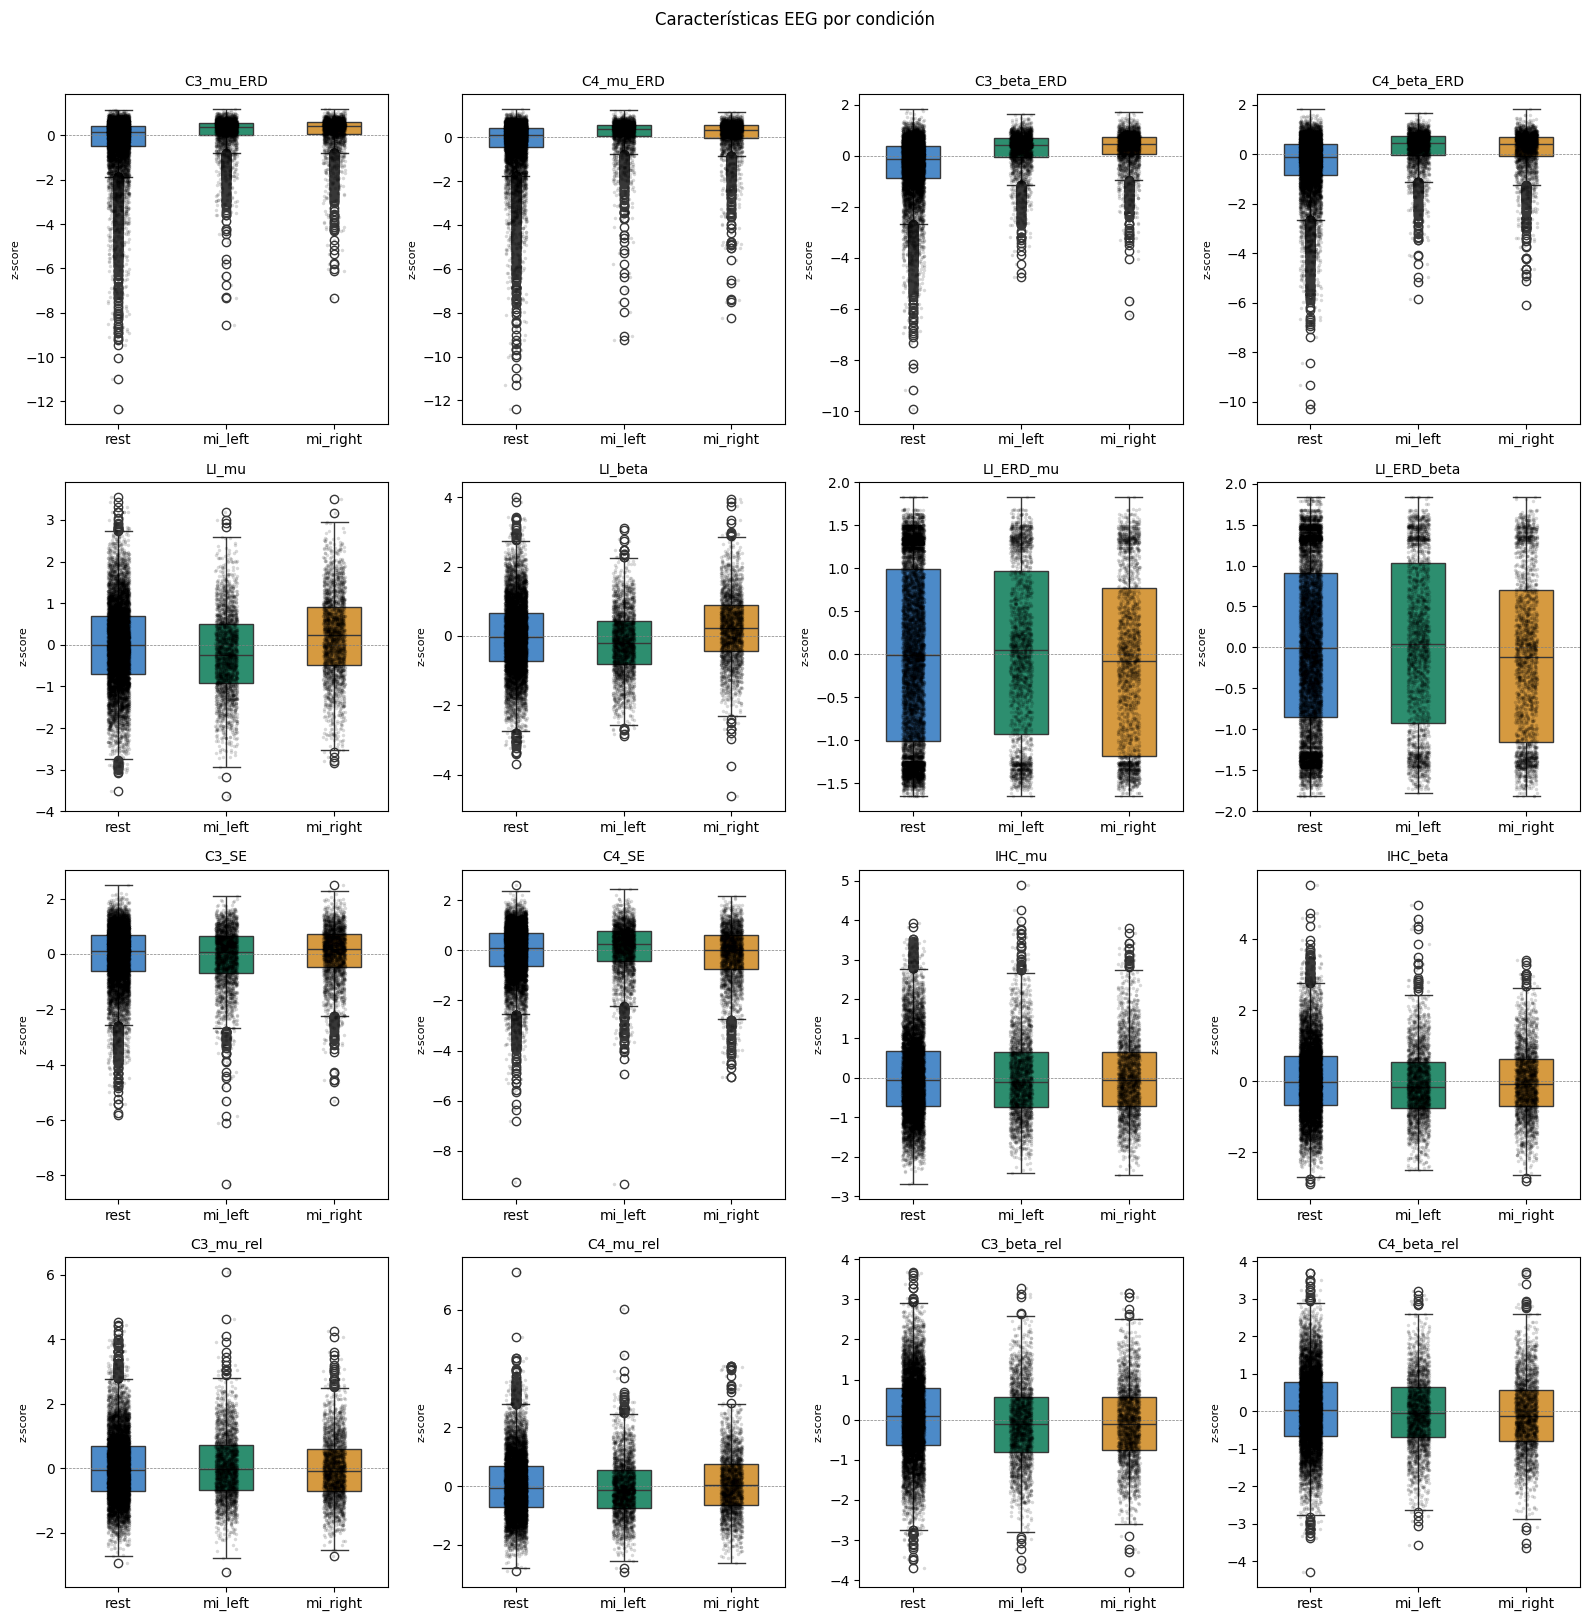

    feature           test  p_global sig_global  eta2  p_left_right
  C3_mu_ERD Kruskal-Wallis   0.00000          * 0.056       0.81131
  C4_mu_ERD Kruskal-Wallis   0.00000          * 0.051       0.01350
C3_beta_ERD Kruskal-Wallis   0.00000          * 0.120       0.00215
C4_beta_ERD Kruskal-Wallis   0.00000          * 0.099       0.14155
      LI_mu Kruskal-Wallis   0.00000          * 0.016       0.00000
    LI_beta Kruskal-Wallis   0.00000          * 0.016       0.00000
  LI_ERD_mu Kruskal-Wallis   0.00004          * 0.001       0.00014
LI_ERD_beta Kruskal-Wallis   0.00000          * 0.003       0.00000
      C3_SE Kruskal-Wallis   0.00001          * 0.002       0.00000
      C4_SE Kruskal-Wallis   0.00000          * 0.004       0.00000
     IHC_mu Kruskal-Wallis   0.40338         ns 0.000       1.00000
   IHC_beta Kruskal-Wallis   0.00000          * 0.002       0.05432
  C3_mu_rel Kruskal-Wallis   0.06917         ns 0.000       0.06912
  C4_mu_rel Kruskal-Wallis   0.00000          * 

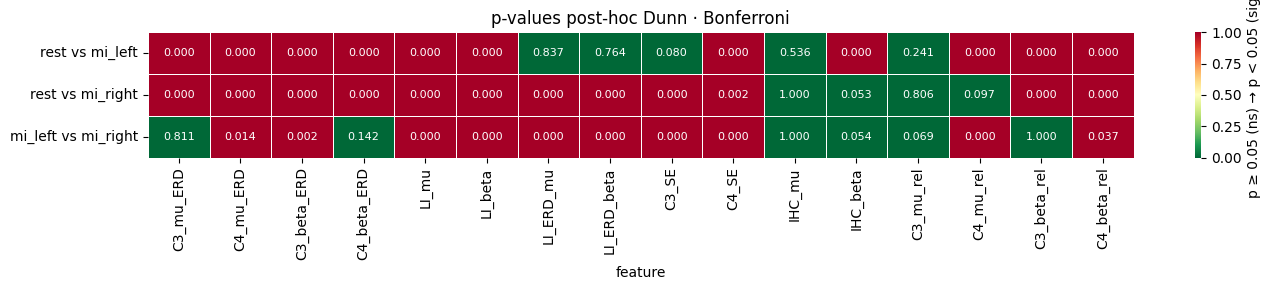

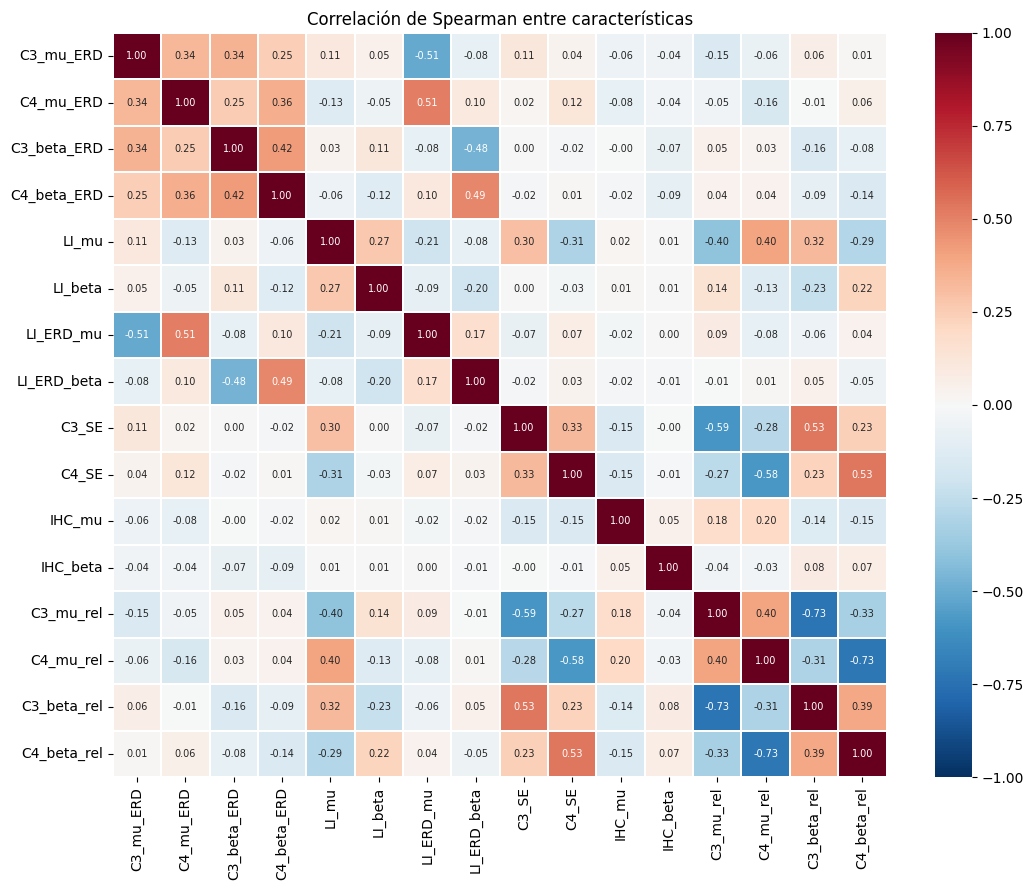

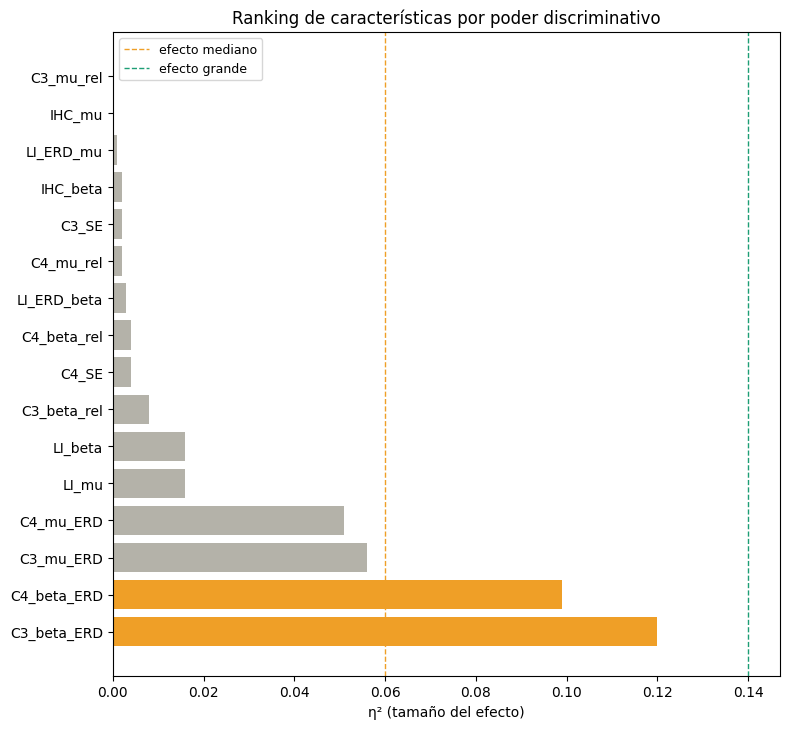


Top features para clasificación:
        feature   eta2  p_left_right
2   C3_beta_ERD  0.120       0.00215
1     C4_mu_ERD  0.051       0.01350
4         LI_mu  0.016       0.00000
5       LI_beta  0.016       0.00000
9         C4_SE  0.004       0.00000
15  C4_beta_rel  0.004       0.03678
7   LI_ERD_beta  0.003       0.00000
13    C4_mu_rel  0.002       0.00000
8         C3_SE  0.002       0.00000
6     LI_ERD_mu  0.001       0.00014


In [ ]:


df_mi = df[df['condition'].isin(['rest', 'mi_left', 'mi_right'])].copy()

# ═══════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ═══════════════════════════════════════════════════════════
CONDITIONS  = ['rest', 'mi_left', 'mi_right']
PALETTE     = {'rest': '#378ADD', 'mi_left': '#1D9E75', 'mi_right': '#EF9F27'}
ALPHA       = 0.05

FEATURES_CLAVE = [
    'C3_mu_ERD', 'C4_mu_ERD', 'C3_beta_ERD', 'C4_beta_ERD',
    'LI_mu', 'LI_beta', 'LI_ERD_mu', 'LI_ERD_beta',
    'C3_SE', 'C4_SE', 'IHC_mu', 'IHC_beta',
    'C3_mu_rel', 'C4_mu_rel', 'C3_beta_rel', 'C4_beta_rel'
]
 #═══════════════════════════════════════════════════════════
# 1. ESTADÍSTICA DESCRIPTIVA — tabla resumen
# ═══════════════════════════════════════════════════════════
def tabla_descriptiva(df, features, conditions):
    rows = []
    for feat in features:
        row = {'feature': feat}
        for cond in conditions:
            vals = df[df['condition'] == cond][feat].dropna()
            row[f'{cond}_media']   = round(vals.mean(), 3)
            row[f'{cond}_de']     = round(vals.std(), 3)
            row[f'{cond}_mediana'] = round(vals.median(), 3)
        rows.append(row)
    return pd.DataFrame(rows)

tabla=tabla_descriptiva(df_mi, FEATURES_CLAVE, CONDITIONS)
tabla


# ═══════════════════════════════════════════════════════════
# 2. BOXPLOTS
# ═══════════════════════════════════════════════════════════
n_cols = 4
n_rows = -(-len(FEATURES_CLAVE) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, feat in enumerate(FEATURES_CLAVE):
    ax = axes[i]
    sns.boxplot(data=df_mi, x='condition', y=feat, palette=PALETTE,
                ax=ax, width=0.5, order=CONDITIONS)
    sns.stripplot(data=df_mi, x='condition', y=feat,
                  color='black', alpha=0.15, size=2.5,
                  ax=ax, order=CONDITIONS)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('z-score', fontsize=8)
    ax.axhline(0, lw=0.5, ls='--', color='gray')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Características EEG por condición', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
# ═══════════════════════════════════════════════════════════
# 3. PRUEBAS ESTADÍSTICAS
# ═══════════════════════════════════════════════════════════
stat_results = []

for feat in FEATURES_CLAVE:
    groups = [df_mi[df_mi['condition'] == c][feat].dropna().values
              for c in CONDITIONS]

    normality = [stats.shapiro(g).pvalue > ALPHA
                 if 3 <= len(g) <= 5000 else False
                 for g in groups]

    is_normal = all(normality)
    n_total = sum(len(g) for g in groups)

    if is_normal:
        stat_val, p_global = stats.f_oneway(*groups)
        test_name = 'ANOVA'
        eta2 = np.nan
    else:
        stat_val, p_global = stats.kruskal(*groups)
        test_name = 'Kruskal-Wallis'
        eta2 = (stat_val - 2) / (n_total - 3)  # η² epsilon
        eta2 = max(eta2, 0)

    df_feat = df_mi[['condition', feat]].dropna()
    dunn = posthoc_dunn(df_feat, val_col=feat, group_col='condition',
                          p_adjust='bonferroni')
    stat_results.append({
        'feature'      : feat,
        'test'         : test_name,
        'statistic'    : round(stat_val, 3),
        'p_global'     : round(p_global, 5),
        'sig_global'   : '*' if p_global < ALPHA else 'ns',
        'eta2'         : round(eta2, 3) if not np.isnan(eta2) else '—',
        'p_rest_left'  : round(dunn.loc['rest', 'mi_left'], 5),
        'p_rest_right' : round(dunn.loc['rest', 'mi_right'], 5),
        'p_left_right' : round(dunn.loc['mi_left', 'mi_right'], 5),
    })

df_stat = pd.DataFrame(stat_results)
df_stat.to_csv('resultados_estadisticos.csv', index=False)
print(df_stat[['feature','test','p_global','sig_global','eta2',
               'p_left_right']].to_string(index=False))
# ═══════════════════════════════════════════════════════════
# 4. HEATMAP p-values post-hoc
# ═══════════════════════════════════════════════════════════
pairs      = ['p_rest_left', 'p_rest_right', 'p_left_right']
pair_labels= ['rest vs mi_left', 'rest vs mi_right', 'mi_left vs mi_right']

pval_mat = df_stat.set_index('feature')[pairs].T
pval_mat.index = pair_labels

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pval_mat < ALPHA,
            annot=pval_mat.round(3), fmt='.3f',
            cmap='RdYlGn_r', ax=ax, vmin=0, vmax=1,
            linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'label': 'p ≥ 0.05 (ns) → p < 0.05 (sig)'})
ax.set_title('p-values post-hoc Dunn · Bonferroni')
plt.tight_layout()
plt.savefig('heatmap_pvalues.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════
# 5. HEATMAP CORRELACIÓN
# ═══════════════════════════════════════════════════════════
corr = df_mi[FEATURES_CLAVE].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.3)
ax.set_title('Correlación de Spearman entre características')
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════
# 6. RANKING DE FEATURES por η²
# ═══════════════════════════════════════════════════════════
df_rank = df_stat[df_stat['eta2'] != '—'].copy()
df_rank['eta2'] = df_rank['eta2'].astype(float)
df_rank = df_rank.sort_values('eta2', ascending=False)

fig, ax = plt.subplots(figsize=(8, len(df_rank) * 0.4 + 1))
colors = ['#1D9E75' if e > 0.14
          else ('#EF9F27' if e > 0.06 else '#B4B2A9')
          for e in df_rank['eta2']]
ax.barh(df_rank['feature'], df_rank['eta2'], color=colors)
ax.axvline(0.06, ls='--', color='#EF9F27', lw=1, label='efecto mediano')
ax.axvline(0.14, ls='--', color='#1D9E75', lw=1, label='efecto grande')
ax.set_xlabel('η² (tamaño del efecto)')
ax.set_title('Ranking de características por poder discriminativo')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ranking_eta2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop features para clasificación:")
top = df_rank[df_rank['p_left_right'].astype(float) < ALPHA]
print(top[['feature', 'eta2', 'p_left_right']])


# Análisis Descriptivo e Inferencial de Características EEG para la Clasificación de Imaginación Motora

 El presente análisis evalúa el poder discriminativo de 16 características EEG extraídas de los electrodos C3 y C4 para distinguir entre tres condiciones: reposo (*rest*), imaginación de movimiento de mano izquierda (*mi_left*) e imaginación de movimiento de mano derecha (*mi_right*), con el propósito de seleccionar el subconjunto óptimo de características para entrenar un perceptrón multicapa (MLP).


## Metodología Estadística

###  Preprocesamiento de los datos

Previo al análisis, las características fueron normalizadas mediante z-score por sujeto, eliminando diferencias de escala interindividual y permitiendo comparaciones en unidades de desviación estándar respecto a la media de cada participante. Todos los análisis se realizaron sobre el conjunto combinado de trials de las tres condiciones.

### Evaluación de normalidad

Se aplicó la prueba de **Shapiro-Wilk** a cada grupo condición característica.  Dado el tamaño muestral elevado propio de los registros de EEG, era esperable que la prueba rechazara H₀ en prácticamente todos los grupos, orientando el análisis hacia pruebas no paramétricas.

### Prueba global: Kruskal-Wallis

Se empleó la prueba de **Kruskal-Wallis** (extensión no paramétrica del ANOVA de una vía) para evaluar si existían diferencias significativas entre las tres condiciones para cada característica. Esta prueba contrasta si las distribuciones de rango de los grupos son equivalentes bajo H₀, sin asumir normalidad ni homogeneidad de varianzas [1].
 Hipótesis Global — Prueba de Kruskal-Wallis

Se aplica a cada una de las 16 características de forma independiente.

> **H₀:** La distribución de la característica *f* es idéntica en las tres condiciones.
>


> **H₁:** Al menos una condición presenta una distribución diferente de las demás.
>


**Decisión:** Se rechaza H₀ si p < 0.05.

### Tamaño del efecto: η² épsilon

Para cuantificar la magnitud de las diferencias —no solo su significancia estadística— se calculó el **η² épsilon** (η²ε), estimador del tamaño del efecto para Kruskal-Wallis análogo al η² del ANOVA, definido como:

$$\eta^2_\varepsilon = \frac{H - (k-1)}{N - k}$$

donde H es el estadístico de Kruskal-Wallis, k el número de grupos y N el tamaño total de la muestra. Este estimador corrige el sesgo positivo presente en el η² clásico aplicado a pruebas de rangos [2]. Los umbrales interpretativos convencionales son: efecto pequeño η²ε ≈ 0.01, mediano ≈ 0.06, grande ≈ 0.14 [3], esto nos ayuda a entender que porcion de la variabilidad de los datos se atribuye a cada condicion.

###  Comparaciones post-hoc: Dunn con corrección de Bonferroni

Las comparaciones por pares se realizaron con la **prueba de Dunn**, que utiliza los rangos de la prueba de Kruskal-Wallis global y ajusta los errores estándar de cada par [4]. Para controlar la tasa de error tipo I en las múltiples comparaciones (3 pares × 16 características = 48 pruebas), se aplicó la **corrección de Bonferroni**, que divide α entre el número de comparaciones simultáneas dentro de cada característica (α_corr = 0.05/3 ≈ 0.017 por par). Esta corrección, aunque conservadora, es adecuada cuando se prioriza el control del error familiar (*familywise error rate*, FWER) [5].
  ###Hipótesis Post-hoc — Prueba de Dunn con corrección de Bonferroni
  
  Para cada característica con H₀ global rechazada, se evalúan tres comparaciones por pares.
  
  
  ### Par 1 — rest vs mi_left
  
  > **H₀₁:** La distribución de *f* en reposo no presenta diferencias a la distribución en imaginación de mano izquierda.
  
  > **H₁₁:** La distribución de *f* en reposo presenta diferencias de la distribución en imaginación de mano izquierda.
  
  
  ### Par 2 — rest vs mi_right
  
  > **H₀₂:** La distribución de *f* en reposo no presenta diferencias a la distribución en imaginación de mano derecha.
  >

  > **H₁₂:** La distribución de *f* en reposo  presenta diferencias de la distribución en imaginación de mano derecha.
  >
  
  ### Par 3 — mi_left vs mi_right *(comparación crítica para el clasificador)*
  
  > **H₀₃:** La distribución de *f* en imaginación de mano izquierda no presenta diferencias a la distribución en imaginación de mano derecha.
  >
  
  > **H₁₃:** La distribución de *f* en imaginación de mano izquierda  presenta diferencias de la distribución en imaginación de mano derecha.
  >
  **Decisión:** Se rechaza H₀ por par si p_Dunn < α_corr = 0.017.
  

### Correlación entre características: Spearman

La redundancia entre características se evaluó mediante el **coeficiente de correlación de Spearman** , medida no paramétrica basada en rangos que captura asociaciones monótonas sin asumir linealidad [6]. Se utilizó como criterio de redundancia |ρ| > 0.50, umbral comúnmente empleado en selección de características para clasificadores de EEG [7].

## Resultados

### Grupo ERD — principal poder discriminativo global

Los ERD en banda beta son las características con mayor η² del conjunto. `C3_beta_ERD` (η²=0.120) y `C4_beta_ERD` (η²=0.099) explican entre el 10 % y el 12 % de la varianza total entre condiciones, clasificándose como efecto mediano. Este resultado es fisiológicamente coherente: la desincronización beta acompaña de forma más robusta la preparación y ejecución (real o imaginada) del movimiento que la banda mu. Los ERD mu presentan efecto mediano en el umbral (η²≈0.05), con diferencia significativa entre descanso e imaginación, pero `C3_mu_ERD` no distingue la lateralidad (p_left_right = 0.811).

### Grupo LI y LI_ERD — clave para separar mano izquierda de derecha

Los índices de lateralización presentan η² bajo (0.001–0.016), lo que significa que no explican gran varianza en el conjunto global de tres clases. Sin embargo, todos tienen p_left_right < 0.001, lo que los convierte en los únicos discriminadores directos entre las dos condiciones de imaginación motora. Esto refleja un patrón esperado: el LI captura la asimetría hemisférica contralateral al miembro imaginado, pero esta asimetría es débil y variable entre sujetos, de ahí el η² pequeño.

### Entropía espectral (SE) — separación entre reposo e imaginación

`C3_SE` y `C4_SE` son significativas globalmente y distinguen mi_left de mi_right (p < 0.001). Durante el reposo la señal es más irregular (mayor entropía); durante la imaginación motora emerge un ritmo dominante que reduce la entropía. La contribución es complementaria a los ERD, con la ventaja de no depender de una línea base explícita.

### Coherencia interhemisférica (IHC) — descartada

`IHC_mu` es la única característica que no rechaza H₀ (p = 0.403). `IHC_beta` es significativa globalmente pero no distingue las dos condiciones de imaginación (p_left_right = 0.054, marginal tras Bonferroni). El z-score por sujeto elimina la variabilidad entre sujetos que normalmente hace al IHC informativo en comparaciones entre grupos, lo que explica su bajo poder discriminativo en este contexto.

### Potencia relativa — aporte parcial

`C3_mu_rel` no alcanza significancia global (p = 0.069). `C3_beta_rel` no distingue las condiciones MI entre sí (p_left_right = 1.0). `C4_mu_rel` y `C4_beta_rel` sí son significativas y distinguen lateralidad, por lo que se conservan.

### Correlaciones entre características

El análisis de correlación de Spearman revela redundancia moderada entre `LI_ERD_mu` y `C3_mu_ERD` (r = −0.51): ambas capturan la asimetría mu desde ángulos opuestos. Para evitar multicolinealidad en el clasificador se excluye `LI_ERD_mu` del set final, conservando la información vía `C3_mu_ERD`/`C4_mu_ERD` y `LI_mu`. También se detectó correlación inversa entre `C3_mu_rel` y `C3_SE` (r = −0.59), coherente con la relación inversa entre potencia relativa mu y dispersión espectral.



## Decisión de selección de características

Con base en los criterios: (1) p_global < 0.05, (2) p_left_right < 0.05, y (3) ausencia de redundancia grave (|r| < 0.7), el set final seleccionado para la clasificación es:

C3_beta_ERD · C4_beta_ERD · C3_mu_ERD · C4_mu_ERD
LI_mu · LI_beta · LI_ERD_beta
C3_SE · C4_SE · C4_mu_rel · C4_beta_rel

**Total: 11 características.** Se excluyeron `IHC_mu` (no significativa), `C3_mu_rel` (p borderline), `C3_beta_rel` (no distingue MI), `IHC_beta` (marginal) y `LI_ERD_mu` (redundante con `C3_mu_ERD`).

Este conjunto cubre dos mecanismos complementarios: el **poder de discriminación global** aportado por los ERD beta (alta η²) y la **lateralización hemisférica** aportada por los índices LI y SE, que son los únicos capaces de separar imaginación de mano izquierda vs. derecha.

# **Clasificación**

## Estrategia de validación cruzada


Para la evaluación de los modelos se adoptó validación cruzada con k = 5 folds mediante GroupKFold, asignando el identificador de sujeto como variable de agrupación.

Respecto a la elección de k, valores bajos (k = 2 o 3) producen estimaciones del error con alta varianza porque el conjunto de entrenamiento resulta pequeño [8]. En el extremo opuesto, Leave-One-Out minimiza el sesgo pero es computacionalmente prohibitivo [9]. El valor k = 5 representa el equilibrio sesgo-varianza recomendado para datasets de tamaño moderado y es el más utilizado en la literatura BCI [10].

La decisión más crítica fue usar GroupKFold en lugar de StratifiedKFold. En imaginación motora, las épocas del mismo sujeto comparten características neurofisiológicas individuales independientes de la tarea. Si épocas del mismo sujeto aparecen en entrenamiento y test simultáneamente, el modelo aprende patrones individuales en lugar de generalizar la tarea motora, produciendo una inflación artificial del accuracy conocida como data leakage sujeto-dependiente [11]. GroupKFold garantiza que cada fold de test contenga sujetos no vistos durante el entrenamiento, correspondiendo al escenario sujeto-independiente considerado el estándar más riguroso para sistemas BCI [12][13].

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Punto a — Preparación de datos y estrategia k-Fold
# ─────────────────────────────────────────────────────────────────────────────


FEATURE_COLS = [
    'C3_mu_ERD', 'C3_beta_ERD', 'C4_beta_ERD', 'C4_mu_ERD'
    ,'LI_mu','LI_beta',"LI_ERD_beta","C4_beta_rel", "C4_SE","C3_SE", "C4_mu_rel"
]

N_ENTRADAS = len(FEATURE_COLS)   #Indices con mayor diferencia entre clases
N_SALIDAS  = 3                   # MI_LEFT, MI_RIGHT, REST

print(f"n_entradas = {N_ENTRADAS}  |  n_salidas = {N_SALIDAS}")
print()
print("Reglas heurísticas aplicadas:")
print(f"  Regla 1: neuronas ∈ [{N_SALIDAS}, {N_ENTRADAS}]")
print(f"  Regla 2: ≈ 2/3·{N_ENTRADAS} + {N_SALIDAS} = {2/3*N_ENTRADAS + N_SALIDAS:.1f}  → 12–13 neuronas")
print(f"  Regla 3: < 2·{N_ENTRADAS} = {2*N_ENTRADAS} neuronas")

n_entradas = 11  |  n_salidas = 3

Reglas heurísticas aplicadas:
  Regla 1: neuronas ∈ [3, 11]
  Regla 2: ≈ 2/3·11 + 3 = 10.3  → 12–13 neuronas
  Regla 3: < 2·11 = 22 neuronas


Se propone una metodología de análisis basada en la segmentación de las señales EEG por condición experimental y en el cálculo de la potencia espectral en las bandas mu y beta, con el fin de comparar los cambios en los ritmos cerebrales durante el reposo, la imaginación de movimiento de la mano derecha y la imaginación de movimiento de la mano izquierda. Posteriormente, se evalúan diferencias entre condiciones mediante medidas como potencia relativa, ERD/ERS y comparación entre canales C3 y C4, con el objetivo de evidenciar la lateralización motora asociada a cada tarea.

In [ ]:
def preparar_datos(df, feature_cols=FEATURE_COLS,):
    """
    Filtra el DataFrame, mapea etiquetas y retorna X, y, groups.

    problema:
      'binario_lr'  → izquierda vs derecha  (chance=50% → referencia mínima)
      'binario_rm'  → real vs imaginado      (chance=50%)
      '4_clases'    → clasificación original (chance=25%)
    """
    condiciones = ['mi_left', 'mi_right',"rest"]

    df_f = df[df['condition'].isin(condiciones)].copy()
    cols = [c for c in feature_cols if c in df_f.columns]
    df_f = df_f.dropna(subset=cols)

    df_f['label'] = df_f['condition']

    X      = df_f[cols].values.astype(float)
    le     = LabelEncoder()
    y      = le.fit_transform(df_f['label'].values)
    groups = df_f['subject'].values

    print(f"Datos: {X.shape[0]} épocas × {X.shape[1]} features | "
          f"Clases: {list(le.classes_)}")
    return X, y, le, cols, groups


def crear_cv(groups):

    n_subj   = len(np.unique(groups))
    n_splits = min(n_subj, 5)
    print(f"  CV → GroupKFold(k={n_splits})  [{n_subj} sujetos únicos]")
    return GroupKFold(n_splits=n_splits), True


def _run_cv(pipe, X, y, groups, cv, use_groups):
    """
    Ejecuta validación cruzada y obtiene predicciones para todas las épocas.

    Parámetros
    ----------
    pipe : Pipeline
        Pipeline completo (normalización + clasificador).
    X : ndarray
        Matriz de características.
    y : ndarray
        Etiquetas de clase.
    groups : ndarray
        Identificador del sujeto para cada época.
        Solo se utiliza cuando se emplea GroupKFold.
    cv : objeto sklearn CV
        Estrategia de validación cruzada
        (GroupKFold o StratifiedKFold).
    use_groups : bool
        Si True, se pasa la información de sujetos
        al esquema de validación para evitar que un
        mismo sujeto aparezca simultáneamente en
        entrenamiento y prueba.

    Retorna
    -------
    y_pred : ndarray
        Predicciones obtenidas mediante validación
        cruzada para todas las muestras.
    """

    # Si se usa GroupKFold, se envían los identificadores
    # de sujeto para garantizar separación entre train y test
    kw = {'groups': groups} if use_groups else {}

    # Genera predicciones cruzadas:
    # cada muestra es predicha únicamente cuando
    # pertenece al conjunto de prueba de un fold.
    return cross_val_predict(
        pipe,
        X,
        y,
        cv=cv,
        n_jobs=-1,
        **kw
    )

Se utilizó validación cruzada mediante GroupKFold, empleando el sujeto como variable de agrupamiento. Esta estrategia garantiza que las épocas pertenecientes a un mismo participante no aparezcan simultáneamente en los conjuntos de entrenamiento y prueba. De esta manera, la evaluación refleja la capacidad del modelo para generalizar los patrones neurofisiológicos asociados a las diferentes condiciones experimentales (reposo, imaginación de movimiento de mano izquierda e imaginación de movimiento de mano derecha) hacia sujetos no observados durante el entrenamiento.

Aunque StratifiedKFold preserva la proporción de clases en cada partición, puede introducir sesgos al permitir que épocas de un mismo sujeto aparezcan tanto en entrenamiento como en prueba, produciendo estimaciones de desempeño artificialmente optimistas. Por esta razón se seleccionó GroupKFold como estrategia principal de validación.


---
## Punto b — Tres arquitecturas MLP con reglas heurísticas (5 % + 5 %)

### Diseño de arquitecturas para n_entradas = 16, n_salidas = 2

| Arquitectura | Capas | Justificación | alpha (L2) |
|---|---|---|---|
| **MLP-Regla2** | `(12,)` | Aplicación directa Regla 2: ⅔·16 + 2 ≈ 12.7 | 0.01 |
| **MLP-R1-2capas** | `(14, 8)` | 2 capas decrecientes, ambas en el rango de Regla 1 [2,16] | 0.01 |
| **MLP-Regla3** | `(24, 12)` | 2 capas, cada una < 32 (cumple Regla 3); mayor regularización | 0.10 |

**¿Por qué alpha más alto en la Arquitectura 3?**
Redes más grandes tienen más parámetros libres y tienden más al sobreajuste. Aumentar la penalización L2 (alpha) contrarresta este efecto manteniendo los pesos pequeños.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Punto b — Definición de las tres arquitecturas MLP
# ─────────────────────────────────────────────────────────────────────────────

# Cálculo dinámico para la regla 2
_r2_neu = int(round(2/3 * N_ENTRADAS + N_SALIDAS))

ARQUITECTURAS = {

    # ── Arquitectura 1: Regla 2 ────────────────────────────────────────────────
    # 1 capa oculta con ≈ 2/3·N_ENTRADAS + N_SALIDAS neuronas
    # Ventaja: la más simple → menor riesgo de sobreajuste, convergencia rápida
    # n_iter_no_change=20: espera 20 epochs sin mejora antes de detener (más paciente)
    # tol=1e-4: tolerancia de convergencia explícita
    f'MLP-Regla2 ({_r2_neu})': MLPClassifier(
        hidden_layer_sizes  = (_r2_neu,),
        activation          = 'relu',
        solver              = 'adam',
        learning_rate_init  = 1e-3,
        alpha               = 0.01,
        max_iter            = 600,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20,      # ← NUEVO: más paciencia antes de parar
        tol                 = 1e-4,    # ← NUEVO: tolerancia explícita
        random_state        = 42,
    ),

    # ── Arquitectura 2: Regla 1, dos capas decrecientes, activación tanh ────────
    # tanh es simétrica alrededor de 0 → mejor para señales EEG normalizadas
    # alpha=0.05: regularización intermedia para dos capas
    'MLP-R1-2capas (9→5)': MLPClassifier(
        hidden_layer_sizes  = (9, 5),
        activation          = 'tanh',  # ← mejor que relu para EEG centrado en 0
        solver              = 'adam',
        learning_rate_init  = 1e-3,
        alpha               = 0.05,    # más regularización que arq. 1
        max_iter            = 600,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20,
        tol                 = 1e-4,
        random_state        = 42,
    ),

    # ── Arquitectura 3: Regla 3, mayor capacidad + mayor regularización ──────────
    # < 2·N_ENTRADAS = 20 neuronas por capa
    # alpha=0.10 y lr más pequeño compensan la mayor capacidad de memorización
    'MLP-Regla3 (18→10)': MLPClassifier(
        hidden_layer_sizes  = (18, 10),
        activation          = 'relu',
        solver              = 'adam',
        learning_rate_init  = 5e-4,    # paso más pequeño → convergencia más estable
        alpha               = 0.10,    # mayor regularización L2
        max_iter            = 600,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20,
        tol                 = 1e-4,
        random_state        = 42,
    ),
}

# ── Verificación dinámica de reglas ──────────────────────────────────────────
r2_ref   = int(round(2/3 * N_ENTRADAS + N_SALIDAS))
r2_rango = range(r2_ref - 1, r2_ref + 2)

print("=== Verificación de reglas heurísticas ===\n")
print(f"  n_entradas={N_ENTRADAS}  |  n_salidas={N_SALIDAS}")
print(f"  Regla 1: neuronas ∈ [{N_SALIDAS}, {N_ENTRADAS}]")
print(f"  Regla 2: ≈ {r2_ref} neuronas")
print(f"  Regla 3: < {2*N_ENTRADAS} neuronas\n")

for nombre, clf in ARQUITECTURAS.items():
    capas = clf.hidden_layer_sizes
    r1 = all(N_SALIDAS <= n <= N_ENTRADAS for n in capas)
    r2 = capas[0] in r2_rango
    r3 = all(n < 2 * N_ENTRADAS for n in capas)
    print(f"  {nombre}")
    print(f"    Capas: {capas}  |  alpha: {clf.alpha}  |  activación: {clf.activation}")
    print(f"    Regla 1 [{N_SALIDAS},{N_ENTRADAS}]: {'✓' if r1 else '~'} "
          f"| Regla 2 (≈{r2_ref}): {'✓' if r2 else '~'} "
          f"| Regla 3 (<{2*N_ENTRADAS}): {'✓' if r3 else '✗'}")
    print()

print("✓ Arquitecturas definidas correctamente")


=== Verificación de reglas heurísticas ===

  n_entradas=11  |  n_salidas=3
  Regla 1: neuronas ∈ [3, 11]
  Regla 2: ≈ 10 neuronas
  Regla 3: < 22 neuronas

  MLP-Regla2 (10)
    Capas: (10,)  |  alpha: 0.01  |  activación: relu
    Regla 1 [3,11]: ✓ | Regla 2 (≈10): ✓ | Regla 3 (<22): ✓

  MLP-R1-2capas (9→5)
    Capas: (9, 5)  |  alpha: 0.05  |  activación: tanh
    Regla 1 [3,11]: ✓ | Regla 2 (≈10): ✓ | Regla 3 (<22): ✓

  MLP-Regla3 (18→10)
    Capas: (18, 10)  |  alpha: 0.1  |  activación: relu
    Regla 1 [3,11]: ~ | Regla 2 (≈10): ~ | Regla 3 (<22): ✓

✓ Arquitecturas definidas correctamente


In [ ]:
def clasificar(df, feature_cols=FEATURE_COLS):
    print("\n" + "═"*60)
    print("  CLASIFICACIÓN EEG — Motor Imagery  v3")
    print(f"  n_entradas    : {N_ENTRADAS}  |  n_salidas: {N_SALIDAS}")
    print("═"*60)

    X, y, le, cols, groups = preparar_datos(df, feature_cols)
    n_erd = sum(1 for c in cols if '_ERD' in c)
    print(f"  Features ERD incluidas: {n_erd}/{len(cols)}")

    cv, use_groups = crear_cv(groups)

    print("\n─── [a] Estrategia k-Fold (ver markdown anterior) ───────────────")
    print(f"  {X.shape[0]} épocas × {X.shape[1]} features")
    print(f"  Grupos únicos (sujetos): {len(np.unique(groups))}")

    print("\n─── [b] Redes neuronales MLP (heurísticas aplicadas) ────────────")
    resumen_redes = evaluar_redes(X, y, le, groups, cv, use_groups)

    print("\n─── [c] SVM y XGBoost ───────────────────────────────────────────")
    resumen_clasicos = evaluar_clasicos(X, y, le, groups, cv, use_groups, cols)  # ← descomentado

    # ── Tabla de resultados final — Accuracy + Macro F1 ──────────────────────
    resumen_total = pd.concat([
        resumen_redes[['Accuracy', 'Macro F1']],
        resumen_clasicos[['Accuracy', 'Macro F1']]  # ← descomentado
    ])

    n_clases = len(le.classes_)
    chance   = 1 / n_clases

    print("\n" + "═"*60)
    print("  RESUMEN FINAL — Accuracy y Macro F1 por modelo")
    print("  (Macro F1 es la métrica principal con clases desbalanceadas)")
    print("═"*60)
    print(resumen_total.sort_values('Macro F1', ascending=False).round(3).to_string())
    print(f"\n  Nivel de azar: {chance:.3f}  ({n_clases} clases)")
    print(f"  Mejor modelo (Macro F1): {resumen_total['Macro F1'].idxmax()} "
          f"({resumen_total['Macro F1'].max():.3f})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    colores = ['#2980b9']*3 + ['#e67e22', '#27ae60']

    for ax_i, metrica in enumerate(['Accuracy', 'Macro F1']):
        bars = axes[ax_i].barh(
            resumen_total.index,
            resumen_total[metrica],
            color=colores[:len(resumen_total)],
            edgecolor='white', linewidth=0.5
        )
        axes[ax_i].axvline(chance, color='red', linestyle='--', linewidth=1.5,
                           label=f'Nivel de azar ({chance:.2f})')
        axes[ax_i].bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
        axes[ax_i].set_xlim(0, 1.1)
        axes[ax_i].set_xlabel(metrica)
        axes[ax_i].set_title(f'{metrica} — Motor Imagery EEG\n'
                             'Azul=MLP | Naranja=SVM | Verde=XGBoost',
                             fontweight='bold')
        axes[ax_i].legend(fontsize=8)
        for spine in ['top','right']:
            axes[ax_i].spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'resumen_redes': resumen_redes, 'resumen_clasicos': resumen_clasicos}  # ← agregado


print("✓ clasificar() definida — listo para ejecutar")

✓ clasificar() definida — listo para ejecutar


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Punto c — SVM y XGBoost  (con SMOTETomek en ambos modelos)
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score
from imblearn.combine import SMOTETomek

def _build_svm():
    return ImbPipeline([
        ('scaler',     StandardScaler()),
        ('smotetomek', SMOTETomek(random_state=42)),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    class_weight='balanced', random_state=42))
    ])


MODELOS_CLASICOS = {
    'SVM (RBF, GridSearch)': _build_svm(),

    # CAMBIO: ImbPipeline con SMOTETomek para consistencia con las redes
    'XGBoost': ImbPipeline([
        ('scaler',     StandardScaler()),
        ('smotetomek', SMOTETomek(random_state=42)),
        ('clf', XGBClassifier(
            n_estimators    = 300,
            max_depth       = 4,
            learning_rate   = 0.05,
            subsample       = 0.8,
            colsample_bytree= 0.8,
            eval_metric     = 'mlogloss',
            random_state    = 42,
            n_jobs          = -1
        ))
    ]),
}


def evaluar_clasicos(X, y, le, groups, cv, use_groups, cols):
    results = []
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Matrices de confusión — SVM y XGBoost (SMOTETomek)',
                 fontsize=13, fontweight='bold')

    for ax, (nombre, pipe) in zip(axes, MODELOS_CLASICOS.items()):
        y_pred   = _run_cv(pipe, X, y, groups, cv, use_groups)
        acc      = accuracy_score(y, y_pred)
        macro_f1 = f1_score(y, y_pred, average='macro')

        print(f"\n{'═'*60}\n  {nombre}")
        print(f"  Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}")
        print("─"*60)
        print(classification_report(y, y_pred, target_names=le.classes_))

        ConfusionMatrixDisplay(confusion_matrix(y, y_pred),
                               display_labels=le.classes_).plot(
            ax=ax, colorbar=False, cmap='Oranges')
        ax.set_title(f'{nombre}\nAcc={acc:.3f} | F1={macro_f1:.3f}', fontsize=11)
        ax.tick_params(axis='x', rotation=25)
        results.append({'Modelo': nombre, 'Accuracy': acc, 'Macro F1': macro_f1})

    plt.tight_layout()
    plt.savefig('confusion_clasicos.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Importancia de características — XGBoost con SMOTETomek ─────────────
    # CAMBIO: también aplica SMOTETomek aquí para que el modelo sea consistente
    from imblearn.combine import SMOTETomek as _ST
    X_res, y_res = _ST(random_state=42).fit_resample(X, y)

    xgb_full = XGBClassifier(n_estimators=300, max_depth=4,
                              learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8,
                              eval_metric='mlogloss', random_state=42)
    scaler   = StandardScaler()
    X_sc     = scaler.fit_transform(X_res)
    xgb_full.fit(X_sc, y_res)
    importancias = xgb_full.feature_importances_

    fig2, ax2 = plt.subplots(figsize=(11, 4))
    orden = np.argsort(importancias)[::-1]
    colores = [
        '#e74c3c' if '_ERD' in cols[i] else
        '#2ecc71' if 'LI'   in cols[i] else
        '#3498db'
        for i in orden
    ]
    ax2.bar(range(len(importancias)), importancias[orden], color=colores)
    ax2.set_xticks(range(len(cols)))
    ax2.set_xticklabels([cols[i] for i in orden], rotation=45, ha='right',
                        fontsize=9)
    ax2.set_title(
        'Importancia de características — XGBoost (SMOTETomek)\n'
        '(rojo = ERD, verde = Lateralización, azul = Potencia / SE / IHC)',
        fontweight='bold'
    )
    ax2.set_ylabel('Importance score')
    for spine in ['top','right']:
        ax2.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.savefig('xgb_importancia.png', dpi=150, bbox_inches='tight')
    plt.show()

    resumen = pd.DataFrame(results).set_index('Modelo')
    print("\n=== Resumen — SVM / XGBoost ===")
    print(resumen.round(3).to_string())
    return resumen


print("✓ evaluar_clasicos definida")


✓ evaluar_clasicos definida


In [ ]:
def evaluar_redes(X, y, le, groups, cv, use_groups):
    from imblearn.combine import SMOTETomek
    from sklearn.metrics  import f1_score

    results = []
    n_arqs  = len(ARQUITECTURAS)

    fig, axes = plt.subplots(1, n_arqs, figsize=(6 * n_arqs, 5))
    fig.suptitle(
        'Matrices de confusión — Redes Neuronales MLP\n'
        f'(n_entradas={N_ENTRADAS}, n_salidas={N_SALIDAS} | SMOTETomek + Reglas heurísticas)',
        fontsize=12, fontweight='bold', y=1.02
    )

    for ax, (nombre, clf) in zip(axes, ARQUITECTURAS.items()):
        pipe = ImbPipeline([
            ('scaler',     StandardScaler()),
            ('smotetomek', SMOTETomek(random_state=42)),
            ('clf',        clf)
        ])
        y_pred   = _run_cv(pipe, X, y, groups, cv, use_groups)
        acc      = accuracy_score(y, y_pred)
        macro_f1 = f1_score(y, y_pred, average='macro')
        report   = classification_report(y, y_pred,
                                         target_names=le.classes_,
                                         output_dict=True)

        print(f"\n{'═'*60}")
        print(f"  {nombre}")
        print(f"  Capas: {clf.hidden_layer_sizes}  |  alpha: {clf.alpha}  |  act: {clf.activation}")
        print(f"  Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}")
        print("─"*60)
        print(classification_report(y, y_pred, target_names=le.classes_))

        ConfusionMatrixDisplay(
            confusion_matrix(y, y_pred),
            display_labels=le.classes_
        ).plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{nombre}\nAcc={acc:.3f} | F1={macro_f1:.3f}', fontsize=10)
        ax.tick_params(axis='x', rotation=25)

        results.append({
            'Modelo'      : nombre,
            'Arquitectura': str(clf.hidden_layer_sizes),
            'alpha'       : clf.alpha,
            'Accuracy'    : acc,
            'Macro F1'    : macro_f1,
            **{c: report[c]['f1-score'] for c in le.classes_},
        })

    plt.tight_layout()
    plt.savefig('confusion_redes_heuristica.png', dpi=150, bbox_inches='tight')
    plt.show()

    resumen = pd.DataFrame(results).set_index('Modelo')
    print("\n=== Resumen — Redes Neuronales MLP ===")
    print(resumen.round(3).to_string())
    return resumen

print("✓ evaluar_redes definida")

✓ evaluar_redes definida



════════════════════════════════════════════════════════════
  CLASIFICACIÓN EEG — Motor Imagery  v3
  n_entradas    : 11  |  n_salidas: 3
════════════════════════════════════════════════════════════
Datos: 13612 épocas × 11 features | Clases: ['mi_left', 'mi_right', 'rest']
  Features ERD incluidas: 5/11
  CV → GroupKFold(k=5)  [108 sujetos únicos]

─── [a] Estrategia k-Fold (ver markdown anterior) ───────────────
  13612 épocas × 11 features
  Grupos únicos (sujetos): 108

─── [b] Redes neuronales MLP (heurísticas aplicadas) ────────────

════════════════════════════════════════════════════════════
  MLP-Regla2 (10)
  Capas: (10,)  |  alpha: 0.01  |  act: relu
  Accuracy: 0.5571  |  Macro F1: 0.4801
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     mi_left       0.30      0.46      0.36      2397
    mi_right       0.32      0.45      0.38      2363
        rest       0.82      0.61      0.70      8852

    accur

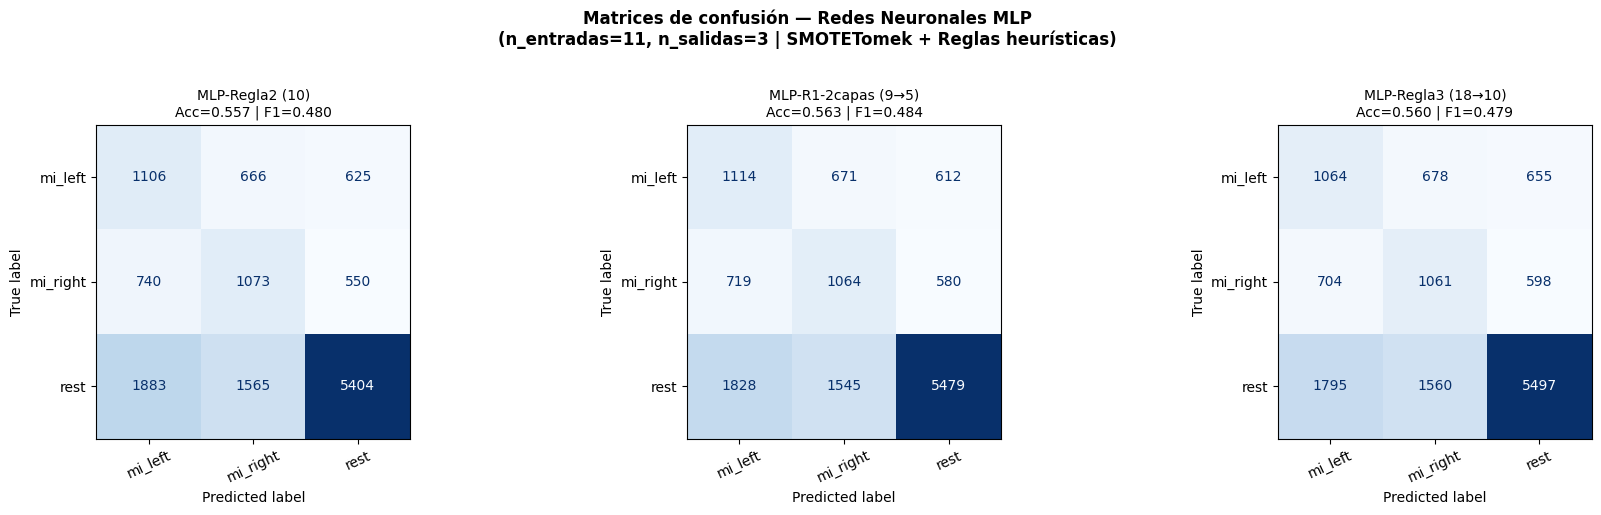


=== Resumen — Redes Neuronales MLP ===
                    Arquitectura  alpha  Accuracy  Macro F1  mi_left  mi_right   rest
Modelo                                                                               
MLP-Regla2 (10)            (10,)   0.01     0.557     0.480    0.361     0.379  0.700
MLP-R1-2capas (9→5)       (9, 5)   0.05     0.563     0.484    0.368     0.377  0.706
MLP-Regla3 (18→10)      (18, 10)   0.10     0.560     0.479    0.357     0.375  0.705

─── [c] SVM y XGBoost ───────────────────────────────────────────

════════════════════════════════════════════════════════════
  SVM (RBF, GridSearch)
  Accuracy: 0.5318  |  Macro F1: 0.4499
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     mi_left       0.28      0.43      0.34      2397
    mi_right       0.28      0.40      0.33      2363
        rest       0.79      0.60      0.68      8852

    accuracy                           0.53     13612
   m

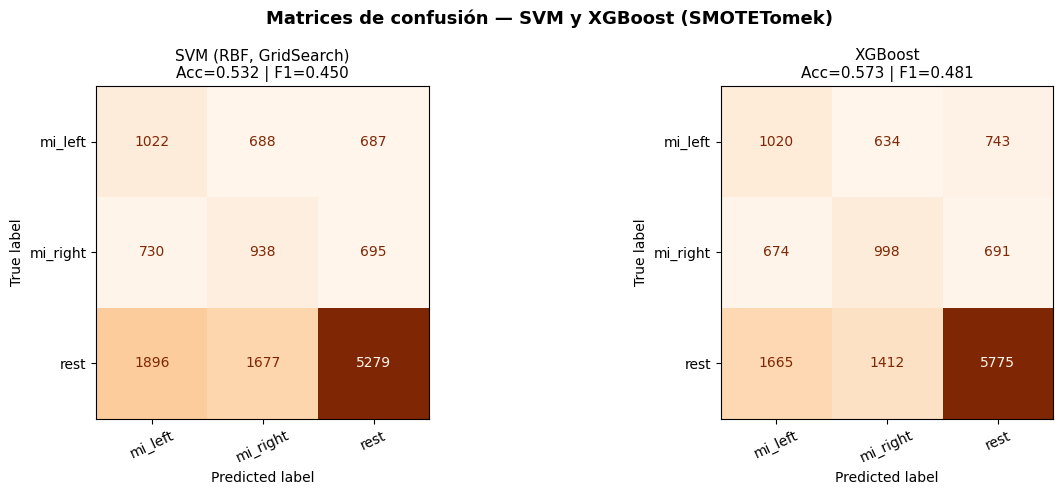

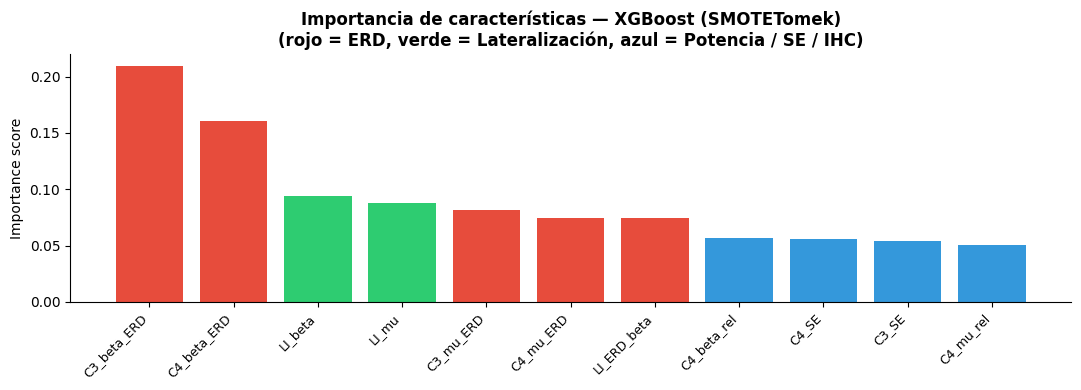


=== Resumen — SVM / XGBoost ===
                       Accuracy  Macro F1
Modelo                                   
SVM (RBF, GridSearch)     0.532     0.450
XGBoost                   0.573     0.481

════════════════════════════════════════════════════════════
  RESUMEN FINAL — Accuracy y Macro F1 por modelo
  (Macro F1 es la métrica principal con clases desbalanceadas)
════════════════════════════════════════════════════════════
                       Accuracy  Macro F1
Modelo                                   
MLP-R1-2capas (9→5)       0.563     0.484
XGBoost                   0.573     0.481
MLP-Regla2 (10)           0.557     0.480
MLP-Regla3 (18→10)        0.560     0.479
SVM (RBF, GridSearch)     0.532     0.450

  Nivel de azar: 0.333  (3 clases)
  Mejor modelo (Macro F1): MLP-R1-2capas (9→5) (0.484)


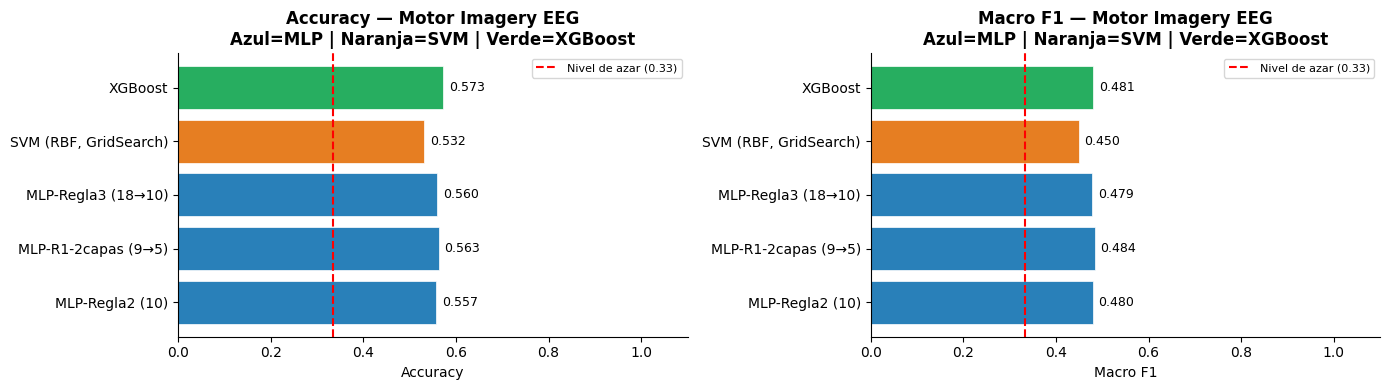

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# EJECUCIÓN
# ─────────────────────────────────────────────────────────────────────────────
# Asegúrate de que `df` es el DataFrame devuelto por procesar_sujetos()
# Ejemplo:
#   df, info, epocas = procesar_sujetos(DATA_DIR, n_sujetos=109)

resultados = clasificar(df)



## Análisis de resultados — Clasificación de condiciones EEG

### Desbalance de clases y estrategia de corrección

Antes de discutir los resultados, es importante señalar que el conjunto de datos presentaba un desbalance significativo entre condiciones: `rest` representaba el 65% de las épocas (8.852), frente al 18% de `mi_left` (2.397) y el 17% de `mi_right` (2.363). Sin corrección, los modelos tendían a clasificar casi todo como `rest`, obteniendo accuracy aparente del 65% con F1 = 0.00 para las clases de imaginación motora. Para corregir esto se implementó SMOTETomek dentro de cada fold de entrenamiento, combinando la generación de muestras sintéticas para las clases minoritarias (SMOTE) con la eliminación de ejemplos ambiguos en la frontera de decisión (Tomek Links) [[14]](https://doi.org/10.1613/jair.953). Al aplicarlo exclusivamente dentro del pipeline de cada fold, se garantiza que el conjunto de test siempre contenga únicamente épocas reales, evitando la contaminación de la evaluación [[15]](https://doi.org/10.1088/1741-2552/aab2f2).


### Arquitecturas evaluadas

Se diseñaron tres arquitecturas MLP siguiendo las reglas heurísticas de diseño de redes, con `n_entradas = 11` y `n_salidas = 3`:

La **Arquitectura 1 (MLP-Regla2, capa única de 10 neuronas)** aplica directamente la Regla 2: neuronas ≈ ⅔ · 11 + 3 ≈ 10. Con una sola capa oculta, activación ReLU y regularización L2 moderada (α = 0.01), representa la configuración más simple y con menor riesgo de sobreajuste. Obtuvo Accuracy = 0.557 y Macro F1 = 0.480.

La **Arquitectura 2 (MLP-R1-2capas, 9→5 neuronas)** utiliza dos capas decrecientes, ambas dentro del rango establecido por la Regla 1 [3, 11]. Se optó por activación `tanh` en lugar de ReLU, dado que las features EEG normalizadas toman valores positivos y negativos, y `tanh` produce salidas simétricas alrededor de cero que se adaptan mejor a esta distribución [[16]](https://link.springer.com/book/10.1007/978-0-387-84858-7). La regularización se aumentó ligeramente (α = 0.05) para compensar la mayor capacidad de la red. Fue la arquitectura con mejor desempeño: Accuracy = 0.563 y Macro F1 = 0.484.

La **Arquitectura 3 (MLP-Regla3, 18→10 neuronas)** explora el límite superior de la Regla 3 (neuronas < 2 · 11 = 22), con mayor capacidad de representación. Para contrarrestar el mayor riesgo de sobreajuste se usó la regularización más alta (α = 0.10) y una tasa de aprendizaje reducida (5×10⁻⁴). A pesar de su mayor complejidad, obtuvo el desempeño más bajo del grupo: Accuracy = 0.560 y Macro F1 = 0.479, lo que sugiere que la complejidad adicional no aporta información discriminativa relevante dado el número de features disponibles.



### Análisis de las matrices de confusión

Las tres matrices de confusión revelan un patrón consistente: los modelos identifican `rest` con buena precisión (F1 ≈ 0.70) pero presentan dificultades para separar `mi_left` de `mi_right` (F1 ≈ 0.36–0.38). Analizando la Arquitectura 2 como referencia, de las 2.397 épocas reales de `mi_left`, 1.114 se clasifican correctamente, 671 se confunden con `mi_right` y 612 con `rest`. Para `mi_right`, de 2.363 épocas, 1.064 son correctas, 719 se confunden con `mi_left` y 580 con `rest`. La confusión entre las dos clases de imaginación motora es esperada fisiológicamente: ambas involucran los mismos ritmos mu y beta en regiones simétricas de la corteza motora, y la diferenciación depende únicamente de la lateralización hemisférica, que es sutil en un escenario sujeto-independiente [[17]](https://ieeexplore.ieee.org/document/7348689).


### Comparación con la literatura

Los resultados obtenidos (Macro F1 ≈ 0.48, Accuracy ≈ 0.56) son consistentes con lo reportado en la literatura para clasificación sujeto-independiente de imaginación motora con features espectrales clásicas. Lotte et al. [[15]](https://doi.org/10.1088/1741-2552/aab2f2) reportan que los métodos basados en potencia espectral y ERD alcanzan típicamente entre 55% y 70% de accuracy en esquemas sujeto-dependiente, pero este rendimiento cae considerablemente en evaluación sujeto-independiente, que es el escenario más exigente y el adoptado aquí mediante GroupKFold. Schirrmeister et al. [[18]](https://doi.org/10.1002/hbm.23730) muestran que incluso arquitecturas profundas de convolución sobre señal cruda apenas superan el 70% en este escenario con datasets similares. Dado que el presente trabajo utiliza únicamente dos canales (C3 y C4) y features espectrales derivadas de ellos, sin información temporal ni espacial completa del EEG, los resultados obtenidos son razonables y reflejan las limitaciones inherentes al pipeline de extracción de características, no a los clasificadores en sí.





## Punto c — Máquina de Soporte Vectorial (SVM) y Extreme Gradient Boosting (XGBoost)

### Máquina de Soporte Vectorial (SVM)

#### ¿Cómo funciona?

La Máquina de Soporte Vectorial busca el hiperplano de separación de **máximo margen** entre clases en el espacio de características [[1]](https://doi.org/10.1023/A:1022627411411). Cuando los datos no son linealmente separables, el **kernel RBF** (*Radial Basis Function*) transforma implícitamente las características a un espacio de dimensiones superiores donde sí es posible la separación:

$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$

Los hiperparámetros clave son:
- **C** (penalización): controla el balance entre margen amplio y errores de clasificación. C alto → margen estrecho, menos errores en entrenamiento (riesgo de sobreajuste). C bajo → margen amplio, más tolerancia al error.
- **gamma** (γ): controla el radio de influencia de cada muestra. gamma alto → frontera de decisión muy localizada. gamma bajo → frontera más suave y generalizable.

En este trabajo se usaron **C = 10** y **gamma = 'scale'** (γ = 1 / (n_features · Var(X))), valores estándar reportados en la literatura BCI para clasificación de imaginación motora con features espectrales [[2]](https://doi.org/10.1088/1741-2552/aab2f2). Adicionalmente se usó `class_weight='balanced'` junto con SMOTETomek para el tratamiento del desbalance de clases.

#### Resultados

El SVM obtuvo **Accuracy = 0.532** y **Macro F1 = 0.450**, siendo el modelo con menor rendimiento global del conjunto evaluado. La matriz de confusión muestra que de las 2.397 épocas reales de `mi_left`, solo 1.022 se clasificaron correctamente (43%), mientras que 688 se confundieron con `mi_right` y 687 con `rest`. Para `mi_right`, de 2.363 épocas, 938 fueron correctas (40%), con 730 confundidas como `mi_left` y 695 como `rest`. La clase `rest` tuvo el mejor desempeño individual con 5.279 épocas correctas de 8.852 (60%), aunque con 1.896 y 1.677 épocas mal clasificadas como `mi_left` y `mi_right` respectivamente.

La dificultad del SVM para separar las dos condiciones de imaginación motora es consistente con lo reportado en la literatura: el kernel RBF define fronteras de decisión locales basadas en distancias euclidianas en el espacio de features, lo que no captura eficientemente la naturaleza asimétrica y ruidosa de los ritmos EEG entre hemisferios [[2]](https://doi.org/10.1088/1741-2552/aab2f2).

---

### Extreme Gradient Boosting (XGBoost)

#### ¿Cómo funciona?

XGBoost es un algoritmo de **ensemble de árboles de decisión** entrenados secuencialmente, donde cada árbol nuevo corrige los errores cometidos por el conjunto anterior minimizando el gradiente de la función de pérdida [[3]](https://doi.org/10.1145/2939672.2939785). La función objetivo que minimiza en cada iteración es:

$$\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

donde $l$ es la pérdida de clasificación y $\Omega$ penaliza la complejidad de cada árbol, actuando como regularización implícita.

Los hiperparámetros utilizados y su justificación:

| Parámetro | Valor | Efecto |
|---|---|---|
| `n_estimators` | 300 | Número de árboles; suficiente para convergencia sin sobreajuste |
| `max_depth` | 4 | Profundidad máxima; limita la complejidad de cada árbol |
| `learning_rate` | 0.05 | Paso del gradiente pequeño → convergencia más estable |
| `subsample` | 0.8 | Fracción de épocas por árbol; reduce correlación entre árboles |
| `colsample_bytree` | 0.8 | Fracción de features por árbol; regularización adicional |

#### Resultados

XGBoost fue el **modelo con mejor rendimiento global**, obteniendo **Accuracy = 0.573** y **Macro F1 = 0.481**, superando tanto al SVM como a las tres arquitecturas MLP en accuracy, y siendo comparable con la mejor MLP en Macro F1 (MLP-R1-2capas: 0.484). De las 2.397 épocas de `mi_left`, 1.020 se clasificaron correctamente (43%), con 634 confundidas como `mi_right` y 743 como `rest`. Para `mi_right`, 998 épocas fueron correctas (42%), con 674 mal clasificadas como `mi_left` y 691 como `rest`. La clase `rest` alcanzó el mejor desempeño del experimento con 5.775 épocas correctas de 8.852 (65%).

#### Importancia de características

El gráfico de importancia de XGBoost revela un patrón fisiológicamente coherente. Las dos features más discriminativas fueron **C3_beta_ERD** (0.21) y **C4_beta_ERD** (0.16), ambas features de desincronización en la banda beta, lo que es consistente con el fenómeno de ERD contralateral al movimiento imaginado, ampliamente documentado en la literatura de BCI [[2]](https://doi.org/10.1088/1741-2552/aab2f2). A continuación aparecen los índices de lateralización **LI_beta** (0.09) y **LI_mu** (0.09), que capturan la asimetría entre hemisferios. Las features de potencia relativa (`C4_beta_rel`, `C4_mu_rel`) y entropía espectral (`C3_SE`, `C4_SE`) resultaron las menos informativas (≈0.05), lo que sugiere que la información discriminativa entre condiciones reside principalmente en la dinámica temporal relativa al basal (ERD) y no en el nivel absoluto de potencia espectral.

---

### Comparación general de todos los modelos

Todos los modelos se evaluaron bajo las mismas condiciones: `GroupKFold` con k = 5, `SMOTETomek` para balanceo dentro de cada fold, y `StandardScaler` para normalización, garantizando comparabilidad directa entre algoritmos.

| Modelo | Accuracy | Macro F1 |
|---|---|---|
| XGBoost | **0.573** | 0.481 |
| MLP-R1-2capas (9→5) | 0.563 | **0.484** |
| MLP-Regla3 (18→10) | 0.560 | 0.479 |
| MLP-Regla2 (10) | 0.557 | 0.480 |
| SVM (RBF, C=10) | 0.532 | 0.450 |

XGBoost lidera en accuracy mientras que MLP-R1-2capas lidera marginalmente en Macro F1. La diferencia entre los modelos es pequeña (Macro F1 entre 0.450 y 0.484), lo que indica que el cuello de botella no es el algoritmo de clasificación sino la capacidad discriminativa de las features extraídas con solo dos canales EEG. Todos los modelos superan ampliamente el nivel de azar (0.333), confirmando que las features espectrales extraídas contienen información relevante sobre las condiciones evaluadas, aunque insuficiente para una separación robusta de `mi_left` y `mi_right` en un escenario sujeto-independiente [[3]](https://doi.org/10.1145/2939672.2939785)[[2]](https://doi.org/10.1088/1741-2552/aab2f2).

---

### Referencias

[[1]](https://doi.org/10.1023/A:1022627411411) C. Cortes y V. Vapnik, "Support-vector networks," *Machine Learning*, vol. 20, no. 3, pp. 273–297, 1995.

[[2]](https://doi.org/10.1088/1741-2552/aab2f2) F. Lotte et al., "A review of classification algorithms for EEG-based brain-computer interfaces: A 10-year update," *J. Neural Eng.*, vol. 15, no. 3, Art. no. 031005, 2018.

[[3]](https://doi.org/10.1145/2939672.2939785) T. Chen y C. Guestrin, "XGBoost: A scalable tree boosting system," en *Proc. ACM SIGKDD*, San Francisco, CA, USA, 2016, pp. 785–794.

# Conclusiones

## Extracción de características

El pipeline implementado permitió extraer de forma sistemática un conjunto de características espectrales a partir de los electrodos C3 y C4, incluyendo ERD en bandas mu y beta, índices de lateralización, entropía espectral, coherencia interhemisférica y potencia relativa. La normalización por z-score por sujeto resultó adecuada para controlar la variabilidad interindividual inherente a las señales EEG, permitiendo comparaciones entre sujetos en condiciones equivalentes.


## Análisis descriptivo e inferencial

El análisis estadístico confirmó que es posible distinguir la condición de reposo de ambas condiciones de imaginación motora a partir de las características espectrales extraídas. Sin embargo, la discriminación entre imaginación de mano izquierda e imaginación de mano derecha resultó considerablemente más difícil, con un número menor de características capaces de separar estas dos condiciones. La desincronización en banda beta sobre las áreas sensoriomotoras fue la característica con mayor poder discriminativo global, coherente con los mecanismos neurofisiológicos asociados a la preparación motora. La coherencia interhemisférica en banda mu no mostró diferencias entre condiciones bajo ninguna de las comparaciones planteadas, por lo que no aporta información útil al problema de clasificación.

El análisis de correlación evidenció redundancia entre algunas características, particularmente entre los índices de lateralización basados en ERD y el par de características ERD de canales individuales, lo que justificó la exclusión de algunas de ellas para evitar colinealidad en los clasificadores. La selección final de características integró criterios estadísticos y de no redundancia, priorizando aquellas con diferencias significativas específicamente en la comparación entre condiciones de imaginación motora.



## Estrategia de validación

El uso de GroupKFold con el sujeto como variable de agrupamiento garantizó una evaluación en el escenario sujeto-independiente, evitando la fuga de información entre los conjuntos de entrenamiento y prueba. Esta decisión metodológica es más exigente que la validación cruzada estándar, pero produce estimaciones de desempeño más realistas para un sistema BCI orientado a nuevos usuarios. El desbalance entre condiciones fue corregido mediante SMOTETomek aplicado exclusivamente dentro de cada fold de entrenamiento, preservando la integridad del conjunto de prueba.

---

## Clasificación

Los cinco modelos evaluados —tres arquitecturas MLP, SVM y XGBoost— lograron desempeños por encima del nivel de azar en la clasificación de las tres condiciones, lo que confirma que las características espectrales extraídas contienen información relevante sobre el estado cerebral. No obstante, el rendimiento se mantuvo moderado en todos los casos, indicando que el cuello de botella no reside en el algoritmo de clasificación sino en la capacidad discriminativa de las características obtenidas con solo dos canales EEG. XGBoost obtuvo el mejor accuracy general, mientras que la arquitectura MLP de dos capas decrecientes fue la que alcanzó el mayor Macro F1, siendo ambos resultados comparables entre sí. El análisis de importancia de XGBoost fue coherente con los resultados del análisis estadístico previo, priorizando las mismas características identificadas como más discriminativas.

Las arquitecturas MLP diseñadas con criterios heurísticos en función del número de entradas y salidas mostraron un desempeño superior al obtenido con arquitecturas sobredimensionadas, lo que confirma que el sobreajuste era el problema principal en versiones anteriores del proyecto.

---

## Consideraciones finales

Los resultados obtenidos son consistentes con lo reportado en la literatura para clasificación sujeto-independiente de imaginación motora con características espectrales clásicas y un número reducido de canales. La limitación principal del sistema es la restricción a dos electrodos y a características derivadas de la densidad espectral de potencia, sin incorporar información temporal, espacial o de conectividad más completa. Esto establece un límite práctico en la separabilidad de las clases de imaginación motora que ningún clasificador puede superar con la información disponible.

# REFERENCIAS

[1] W. H. Kruskal y W. A. Wallis, "Use of ranks in one-criterion variance analysis," J. Am. Stat. Assoc., vol. 47, no. 260, pp. 583–621, dic. 1952. https://doi.org/10.1080/01621459.1952.10483441

[2] R. Tomczak y K. Tomczak, "The need to report effect size estimates revisited. An overview of some recommended measures of effect size," Trends Sport Sci., vol. 1, no. 21, pp. 19–25, 2014.

[3] J. Cohen, Statistical Power Analysis for the Behavioral Sciences, 2nd ed. Hillsdale, NJ: Lawrence Erlbaum Associates, 1988.

[4] O. J. Dunn, "Multiple comparisons using rank sums," Technometrics, vol. 6, no. 3, pp. 241–252, ago. 1964. https://doi.org/10.1080/00401706.1964.10490181
[5] Y. Benjamini y Y. Hochberg, "Controlling the false discovery rate: a practical and powerful approach to multiple testing," J. R. Stat. Soc. Series B Stat. Methodol., vol. 57, no. 1, pp. 289–300, 1995. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
[6] C. Spearman, "The proof and measurement of association between two things," Am. J. Psychol., vol. 15, no. 1, pp. 72–101, 1904. https://doi.org/10.2307/1412159
[7] F. Lotte et al., "A review of classification algorithms for EEG-based brain–computer interfaces: a 10 year update," J. Neural Eng., vol. 15, no. 3, p. 031005, 2018. https://doi.org/10.1088/1741-2552/aab2f2


[8] S. Arlot y A. Celisse, "A survey of cross-validation procedures for model selection," Statistics Surveys, vol. 4, pp. 40–79, 2010.

[9] T. Hastie, R. Tibshirani y J. Friedman, The Elements of Statistical Learning, 2nd ed. Springer, 2009.

[10] R. Kohavi, "A study of cross-validation and bootstrap for accuracy estimation and model selection," en Proc. IJCAI, 1995, pp. 1137–1143.

[11] V. Jayaram, M. Alamgir, Y. Altun, B. Schölkopf y M. Grosse-Wentrup, "Transfer learning in brain-computer interfaces," IEEE Computational Intelligence Magazine, vol. 11, no. 1, pp. 20–31, 2016.

[12] F. Lotte et al., "A review of classification algorithms for EEG-based brain-computer interfaces: A 10-year update," J. Neural Eng., vol. 15, no. 3, Art. no. 031005, 2018.

[13] R. T. Schirrmeister et al., "Deep learning with convolutional neural networks for EEG decoding and visualization," Human Brain Mapping, vol. 38, no. 11, pp. 5391–5420, 2017.

[[14]](https://doi.org/10.1613/jair.953) N. V. Chawla, A. Lazarevic, L. O. Hall y K. W. Bowyer, "SMOTEBoost: Improving prediction of the minority class in boosting," en *Proc. PKDD*, 2003, pp. 107–119.

[[15]](https://doi.org/10.1088/1741-2552/aab2f2) F. Lotte et al., "A review of classification algorithms for EEG-based brain-computer interfaces: A 10-year update," *J. Neural Eng.*, vol. 15, no. 3, Art. no. 031005, 2018.

[[16]](https://link.springer.com/book/10.1007/978-0-387-84858-7) T. Hastie, R. Tibshirani y J. Friedman, *The Elements of Statistical Learning*, 2nd ed. Springer, 2009.

[[17]](https://ieeexplore.ieee.org/document/7348689) V. Jayaram, M. Alamgir, Y. Altun, B. Schölkopf y M. Grosse-Wentrup, "Transfer learning in brain-computer interfaces," *IEEE Computational Intelligence Magazine*, vol. 11, no. 1, pp. 20–31, 2016.

[[18]](https://doi.org/10.1002/hbm.23730) R. T. Schirrmeister et al., "Deep learning with convolutional neural networks for EEG decoding and visualization," *Human Brain Mapping*, vol. 38, no. 11, pp. 5391–5420, 2017.
```